In [5]:
import pandas as pd

df = pd.read_csv("data/churn.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df = df.drop(
    ["RowNumber", "CustomerId", "Surname"],
    axis=1
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
total_customers = len(df)

churn_customers = df["Exited"].sum()

churn_rate = round(
    churn_customers / total_customers * 100,
    2
)

print("Total Customers:", total_customers)
print("Churn Customers:", churn_customers)
print("Churn Rate:", churn_rate, "%")

Total Customers: 10000
Churn Customers: 2037
Churn Rate: 20.37 %


In [11]:
import os

os.makedirs("visuals", exist_ok=True)

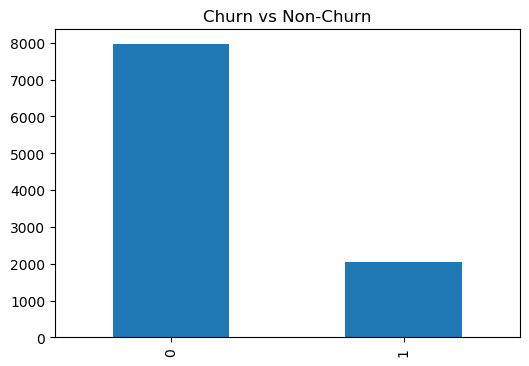

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Exited"].value_counts().plot(
    kind="bar"
)

plt.title("Churn vs Non-Churn")

plt.savefig(
    "visuals/chart1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

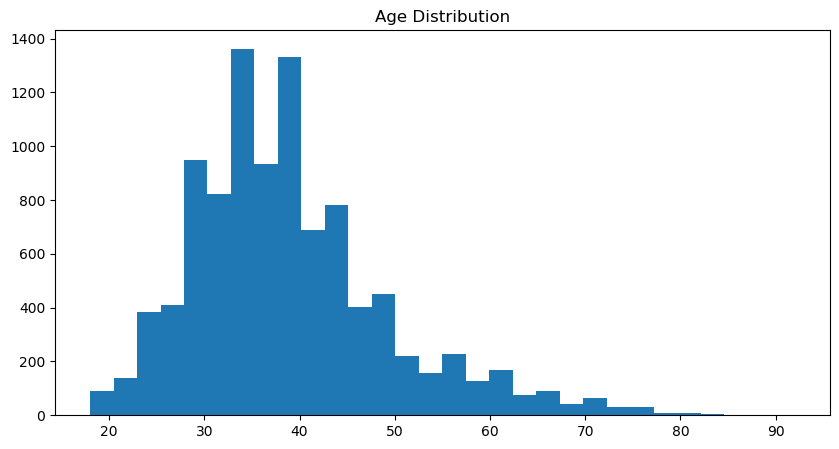

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Age"],
    bins=30
)

plt.title("Age Distribution")

plt.savefig(
    "visuals/chart2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

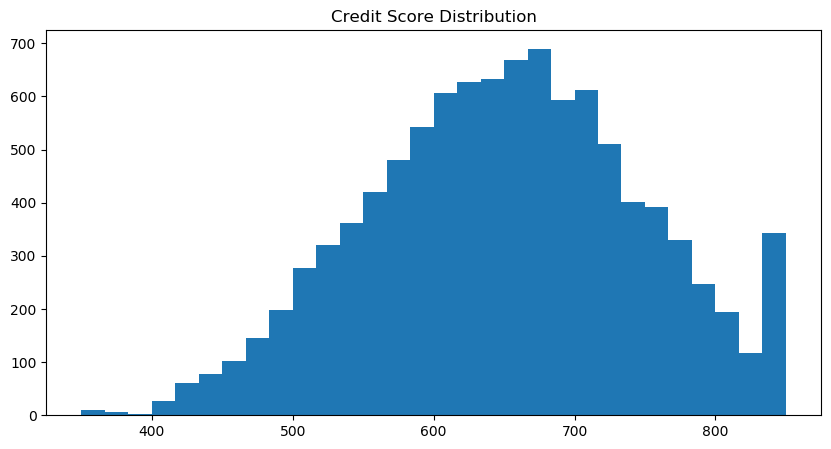

In [14]:
plt.figure(figsize=(10,5))

plt.hist(
    df["CreditScore"],
    bins=30
)

plt.title("Credit Score Distribution")

plt.savefig(
    "visuals/chart3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

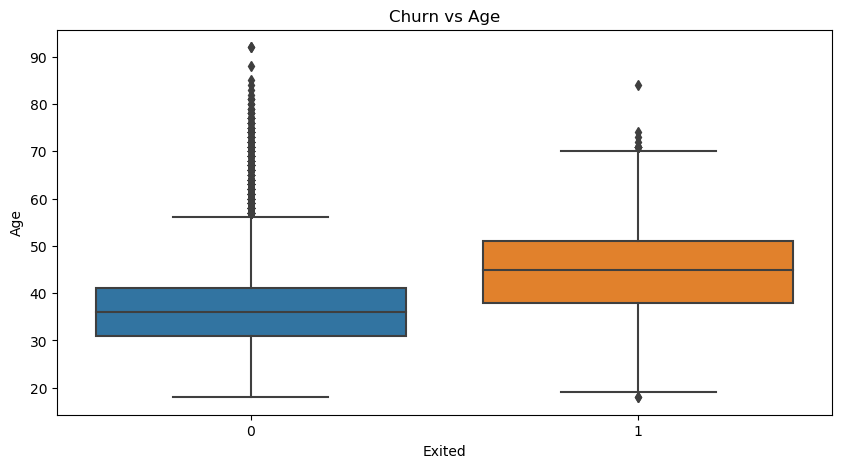

In [15]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

plt.title("Churn vs Age")

plt.savefig(
    "visuals/chart4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

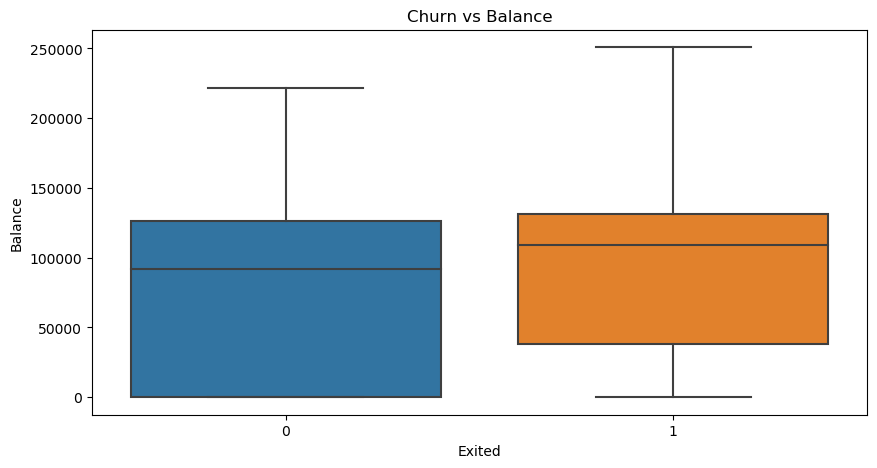

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.title("Churn vs Balance")

plt.savefig(
    "visuals/chart5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

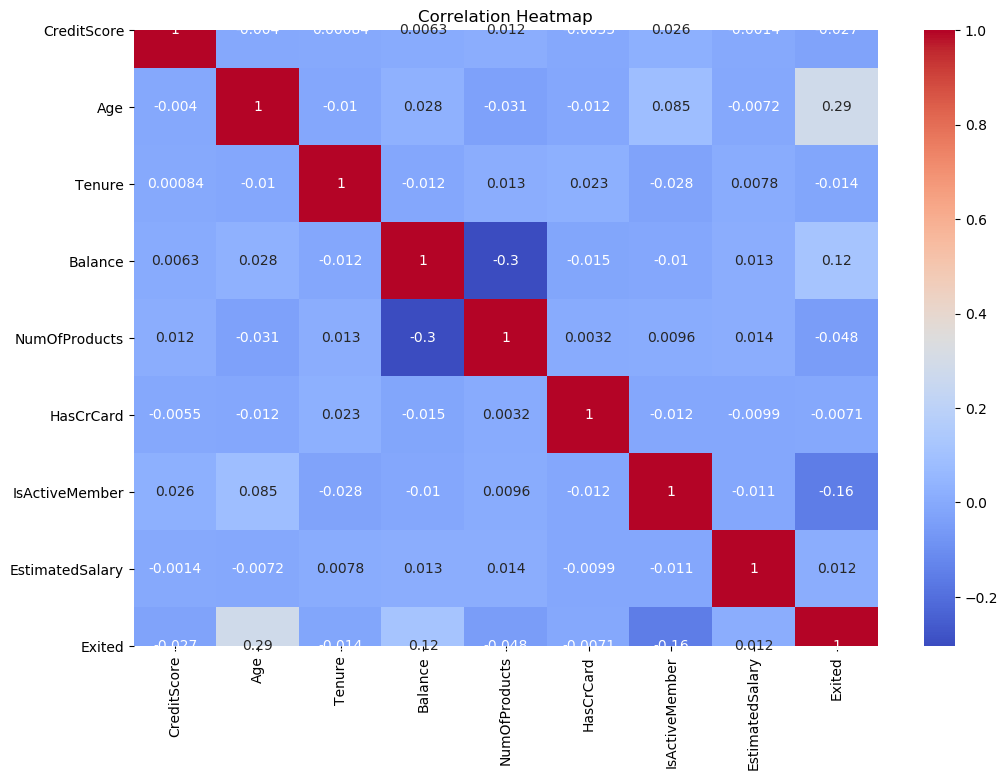

In [18]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/chart6.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import os

for file in sorted(os.listdir("visuals")):
    print(file, os.path.getsize("visuals/" + file))

chart1.png 44943
chart2.png 57658
chart3.png 59818
chart4.png 60198
chart5.png 54959
chart6.png 340720
